<a href="https://colab.research.google.com/github/SathyaS-17/Machine-Learning/blob/main/MachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Experiment-1 Implementation of Find-S and Candidate Elimination Algorithm**

In [6]:
import pandas as pd
 #----Step 1: Load dataset---4 # You can either: 5 # (a) define directly inside code (default here) 6 # (b) upload a CSV file instead 7 # 8 # Example dataset: EnjoySport 9
data = pd.DataFrame([ ['Sunny', 'Warm', 'Normal', 'Strong', 'Warm', 'Same', 'Yes'],
                      ['Sunny', 'Warm', 'High', 'Strong', 'Warm', 'Same', 'Yes'],
                       ['Rainy', 'Cold', 'High', 'Strong', 'Warm', 'Change', 'No'],
                       ['Sunny', 'Warm', 'High', 'Strong', 'Cool', 'Change', 'Yes']
                       ],
              columns=['Sky','AirTemp','Humidity','Wind','Water','Forecast', 'EnjoySport'])
print("Dataset:\n", data)
  # Attributes and target
attributes = data.columns[:-1]
target = data.columns[-1]

def find_s(df):
  hypothesis = ['0'] * (len(df.columns)- 1)
  for i, row in df.iterrows():
     if row[target] == "Yes":
      for j in range(len(hypothesis)):
       if hypothesis[j] == '0':
          hypothesis[j] = row[j]
       elif hypothesis[j] != row[j]:
           hypothesis[j] = '?'
  return hypothesis
final_hypothesis = find_s(data)
print("\nMost specific hypothesis (Find-S):", final_hypothesis)

def candidate_elimination(df):
  S = [['0'] * (len(df.columns)- 1)]
  G = [['?'] * (len(df.columns)- 1)]
  for i, row in df.iterrows():
     if row[target] == "Yes":
       G = [g for g in G if all(g[j] == '?' or g[j] == row[j ] for j in range(len(attributes)))]
       for j in range(len(attributes)):
         if S[0][j] == '0':
           S[0][j] = row[j]
         elif S[0][j] != row[j]:
           S[0][j] = '?'
     else: # negative 58 # Remove from S any inconsistent hypothesis
        S = [s for s in S if not all(s[j] == '?' or s[j] == row[j] for j in range(len(attributes)))]
        new_G = []
        for g in G:
            for j in range(len(attributes)):
               if g[j] == '?':
                 for val in df[attributes[j]].unique():
                   if val != row[j]:
                     new_hypo = g.copy()
                     new_hypo[j] = val
                     if any(all(s[k] == '?' or s[k] == new_hypo[k] or s[k] == '0' for k in range(len(attributes) )) for s in S):
                         new_G.append(new_hypo)
        G = new_G
  return S, G
S_final, G_final = candidate_elimination(data)
print("\nCandidate Elimination results:")
print("S (Most specific boundary):", S_final)
print("G (Most general boundary):", G_final)

Dataset:
      Sky AirTemp Humidity    Wind Water Forecast EnjoySport
0  Sunny    Warm   Normal  Strong  Warm     Same        Yes
1  Sunny    Warm     High  Strong  Warm     Same        Yes
2  Rainy    Cold     High  Strong  Warm   Change         No
3  Sunny    Warm     High  Strong  Cool   Change        Yes

Most specific hypothesis (Find-S): ['Sunny', 'Warm', '?', 'Strong', '?', '?']

Candidate Elimination results:
S (Most specific boundary): [['Sunny', 'Warm', '?', 'Strong', '?', '?']]
G (Most general boundary): []


/tmp/ipykernel_404/1843710080.py:20: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  hypothesis[j] = row[j]
/tmp/ipykernel_404/1843710080.py:21: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  elif hypothesis[j] != row[j]:
/tmp/ipykernel_404/1843710080.py:35: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  S[0][j] = row[j]
/tmp/ipykernel_404/1843710080.py:36: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a

**Experiment-2 Implementation of RIPPER and FOIL Algorithms**

In [9]:
!pip install wittgenstein pandas scikit-learn
import pandas as pd
from sklearn.datasets import load_iris
import wittgenstein as lw
#----Step 1: Load dataset (Iris for demo)---
iris = load_iris(as_frame=True)
X = iris.data
y = iris.target
df = pd.concat([X, y.rename("target")], axis=1)
print("Dataset head:\n", df.head())

model = lw.RIPPER()
model.fit(X, y, pos_class=0)
print("\n=== RIPPER Rules ===")
print(model.ruleset_)  #----Step 3: Simplified FOIL Implementation---24 # FOIL tries to build rules like "IF ... THEN class" 25 # We’ll demonstrate with binary classification subset (setosa vs not-setosa)
df_bin = df.copy()
df_bin['target'] = (df_bin['target'] == 0).astype(int)
attributes = list(X.columns)
def foil_gain(pos_before, neg_before, pos_after, neg_after):
  if pos_after == 0: return-1e9
  return pos_after * ( ((pos_after)/(pos_after+neg_after))- (( pos_before)/(pos_before+neg_before)) )
def foil(df, target_col='target'):
  rules = []
  pos_total = df[target_col].sum()
  neg_total = len(df)- pos_total
  while pos_total > 0:
    rule = []
    pos_rem, neg_rem = pos_total, neg_total
    covered = df.copy()
    while neg_rem > 0:
      best_gain, best_attr =-1e9, None
      for attr in attributes:
        for val in df[attr].unique():
          subset = covered[covered[attr] == val]
          pos_after = subset[target_col].sum()
          neg_after = len(subset)- pos_after
          gain = foil_gain(pos_rem, neg_rem, pos_after, neg_after)
          if gain > best_gain:
            best_gain, best_attr, best_val, best_subset = gain, attr, val, subset
      if best_attr is None: break
      rule.append((best_attr, best_val))
      covered = best_subset
      pos_rem, neg_rem = covered[target_col].sum(), len( covered)- covered[target_col].sum()
    rules.append((rule, 1))
    df = df.drop(covered.index)
    pos_total = df[target_col].sum()
    neg_total = len(df)- pos_total
  return rules
rules = foil(df_bin)
print("\n=== FOIL Learned Rules (Setosa vs Not) ===")
for conds, pred in rules:
  cond_str = " AND ".join([f"{a}={v}" for a,v in conds])
  print(f"IF {cond_str} THEN class={pred}")

Dataset head:
    sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   target  
0       0  
1       0  
2       0  
3       0  
4       0  

=== RIPPER Rules ===
[[petalwidth(cm)=<0.2] V [petalwidth(cm)=0.2-0.4] V [petallength(cm)=1.5-1.7]]

=== FOIL Learned Rules (Setosa vs Not) ===
IF petal width (cm)=0.2 THEN class=1
IF petal width (cm)=0.4 THEN class=1
IF petal width (cm)=0.3 THEN class=1
IF petal width (cm)=0.1 THEN class=1
IF sepal width (cm)=3.5 THEN class=1
IF petal length (cm)=1.7 THEN class=1


**Experiment-3 Implementation of Bagging and Boosting**

In [ ]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier,AdaBoostClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
data=load_breast_cancer()
X=pd.DataFrame(data.data,columns=data.feature_names)
y=pd.DataFrame(data.target)
print("Dataset shape:",X.shape)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
bag_model=BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=50,random_state=42)
bag_model.fit(X_train,y_train)
y_pred_bag=bag_model.predict(X_test)
print("\n=== Bagging Results ===")
print("Accuracy:",accuracy_score(y_test,y_pred_bag))
#print("Confusion Matrix:\n",confusion_matrix(y_test,y_pred_bag))
print("Classification Report:\n",classification_report(y_test,y_pred_bag))
boost_model=AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),n_estimators=50,random_state=42)
boost_model.fit(X_train,y_train)
y_pred_boost=boost_model.predict(X_test)
print("\n=== Boosting Results(Ada Boost) ===")
print("Accuracy:",accuracy_score(y_test,y_pred_boost))
print("Classsification Report:\n",classification_report(y_test,y_pred_boost))
print("Confusion Matrix Bagging:\n",confusion_matrix(y_test,y_pred_bag))
print("\nConfusion Matrix -Boosting \n",confusion_matrix(y_test,y_pred_boost))

Dataset shape: (569, 30)


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_bagging.py:878: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



=== Bagging Results ===
Accuracy: 0.9385964912280702
Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.90      0.92        42
           1       0.95      0.96      0.95        72

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)



=== Boosting Results(Ada Boost) ===
Accuracy: 0.956140350877193
Classsification Report:
               precision    recall  f1-score   support

           0       0.97      0.90      0.94        42
           1       0.95      0.99      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

Confusion Matrix Bagging:
 [[38  4]
 [ 3 69]]

Confusion Matrix -Boosting 
 [[38  4]
 [ 1 71]]


**Experiment-4 K Means Clustering on Iris Dataset**

Dataset Shape (150, 4)

 Sample clusteres data :
     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   cluster  
0        1  
1        1  
2        1  
3        1  
4        1  


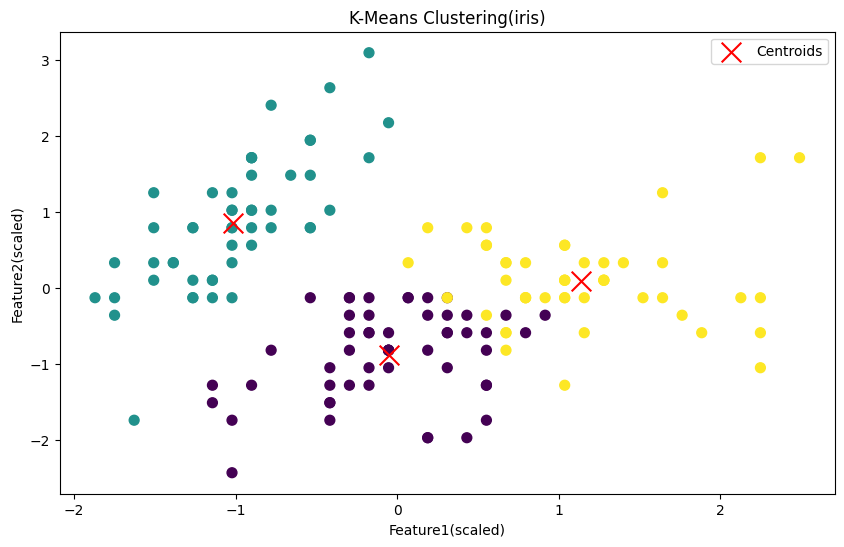

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
iris=load_iris(as_frame=True)
X=iris.data
print("Dataset Shape",X.shape)
scaler=StandardScaler()
X_scaled=scaler.fit_transform(X)
k=3
kmeans=KMeans(n_clusters=k,random_state=42,n_init=10)
clusters=kmeans.fit_predict(X_scaled)
X_clustered=X.copy()
X_clustered['cluster']=clusters
print("\n Sample clusteres data :\n ",X_clustered.head())
plt.figure(figsize=(10,6))
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=clusters,cmap='viridis',s=50)
plt.scatter(kmeans.cluster_centers_[:,0],kmeans.cluster_centers_[:,1],c='red',marker='x',s=200,label='Centroids')
plt.title('K-Means Clustering(iris)')
plt.xlabel('Feature1(scaled)')
plt.ylabel('Feature2(scaled)')
plt.legend()
plt.show()